# Lesson 1: What Is Machine Learning?

## Hands-on Notebook: Teach the Computer to Predict Ice Cream Sales

In this notebook, you will build your first simple machine learning model.

The model will learn from past data about **temperature** and **ice cream sales**, then predict how many ice cream cones might be sold on a new day.

This notebook is designed for high school students who already know basic Python and data science.

# Learning Objectives

By the end of this notebook, you will be able to:

1. Explain the difference between traditional programming and machine learning.
2. Identify features, labels, training data, and test data.
3. Use `pandas` to create and inspect a dataset.
4. Use `matplotlib` to visualize data.
5. Use `scikit-learn` to train a simple machine learning model.
6. Make predictions using a trained model.
7. Evaluate model performance using a simple error metric.
8. Improve a model by adding another useful feature.

# Part 1: Background

## Traditional Programming vs. Machine Learning

In traditional programming, a human writes specific rules.

Example:

```python
if temperature > 80:
    sales = "high"
else:
    sales = "low"
```

In machine learning, we give the computer examples. The computer learns a pattern from data.

Example:

| Temperature | Ice Cream Sales |
|---|---|
| 60°F | 45 |
| 70°F | 60 |
| 80°F | 76 |
| 90°F | 95 |

The model learns:

> Higher temperature usually means higher ice cream sales.

## Important Vocabulary

| Term | Simple Meaning |
|---|---|
| Feature | Input used to make a prediction |
| Label | Output we want to predict |
| Model | A learned pattern from data |
| Training data | Data used to teach the model |
| Test data | Data used to check the model |
| Prediction | The model's guess |
| Error | How far the prediction is from the real answer |

## Part 1 Code: Import Libraries

Run the cell below to import the libraries we need.

In [1]:
# pandas helps us create and work with tables of data.
import pandas as pd

# numpy helps us work with numbers and arrays.
import numpy as np

# matplotlib helps us create charts and graphs.
import matplotlib.pyplot as plt

# LinearRegression is a simple machine learning model for predicting numbers.
from sklearn.linear_model import LinearRegression

# train_test_split helps us divide data into training data and test data.
from sklearn.model_selection import train_test_split

# mean_absolute_error helps us measure how wrong our predictions are on average.
from sklearn.metrics import mean_absolute_error

print("Libraries imported successfully!")

Libraries imported successfully!


# Part 2: Load the Dataset

For Lesson 1, we will use a small dataset that is easy to understand.

Each row represents one day.

| Column | Meaning |
|---|---|
| `temperature` | Outdoor temperature in Fahrenheit |
| `ice_cream_sales` | Number of ice cream cones sold |

This is a small artificial dataset created for learning.

## Student TODO: Create the Dataset

Complete the missing parts in the code below.

In [2]:
# TODO: Create a dictionary named data.
# The dictionary should contain two columns:
# 1. "temperature"
# 2. "ice_cream_sales"

data = {
    "temperature": [55, 58, 60, 63, 65, 68, 70, 72, 75, 78, 80, 83, 85, 88, 90],
    "ice_cream_sales": [40, 42, 45, 48, 52, 56, 60, 63, 68, 72, 76, 82, 85, 90, 95]
}

# TODO: Convert the dictionary into a pandas DataFrame.
df = pd.DataFrame(data)

# TODO: Display the first 5 rows.
df.head()

,temperature,ice_cream_sales
0,55,40
1,58,42
2,60,45
3,63,48
4,65,52


## Teacher Solution: Load the Dataset

Use this section if students need help or after they finish the TODO version.

In [3]:
# Teacher Solution

# Create a small dataset using a Python dictionary.
data_solution = {
    "temperature": [55, 58, 60, 63, 65, 68, 70, 72, 75, 78, 80, 83, 85, 88, 90],
    "ice_cream_sales": [40, 42, 45, 48, 52, 56, 60, 63, 68, 72, 76, 82, 85, 90, 95]
}

# Convert the dictionary into a pandas DataFrame.
df_solution = pd.DataFrame(data_solution)

# Display the dataset.
df_solution

,temperature,ice_cream_sales
0,55,40
1,58,42
2,60,45
3,63,48
4,65,52
5,68,56
6,70,60
7,72,63
8,75,68
9,78,72


# Part 3: Explore the Data

Before training a model, we should understand the data.

We will check:

1. How many rows and columns the dataset has.
2. Basic summary statistics.
3. Whether there is a visible pattern.

## Student TODO: Inspect the Data

In [4]:
# TODO: Print the number of rows and columns.
print("Dataset shape:", df.shape)

# TODO: Show basic summary statistics.
df.describe()

Dataset shape: (15, 2)


,temperature,ice_cream_sales
count,15.000000,15.000000
mean,72.666667,64.933333
std,11.184598,17.958152
min,55.000000,40.000000
25%,64.000000,50.000000
50%,72.000000,63.000000
75%,81.500000,79.000000
max,90.000000,95.000000


## Student TODO: Visualize the Data

A scatter plot helps us see whether two variables are related.

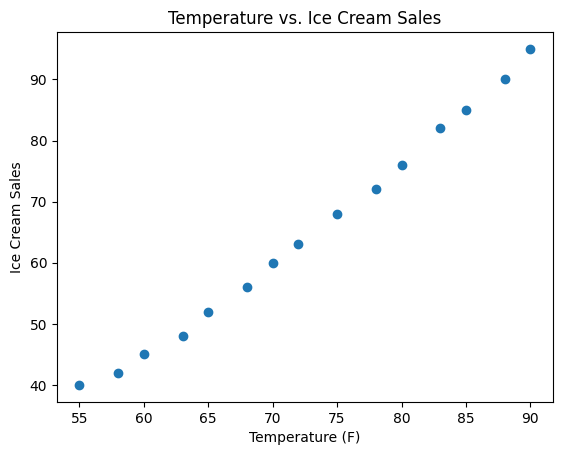

In [5]:
# TODO: Create a scatter plot.
plt.scatter(df["temperature"], df["ice_cream_sales"])

# TODO: Add x-axis label.
plt.xlabel("Temperature (F)")

# TODO: Add y-axis label.
plt.ylabel("Ice Cream Sales")

# TODO: Add chart title.
plt.title("Temperature vs. Ice Cream Sales")

# Show the chart.
plt.show()

## Think About It

Answer these questions:

1. What pattern do you see in the chart?
2. When temperature increases, what usually happens to ice cream sales?
3. Do you think temperature is a useful feature for predicting ice cream sales?

# Part 4: Prepare the Data

In machine learning, we usually separate data into:

- `X`: the input features
- `y`: the output label

For this first model:

| Role | Column |
|---|---|
| Feature, `X` | `temperature` |
| Label, `y` | `ice_cream_sales` |

Important: scikit-learn expects `X` to be a 2D table, so we use double brackets:

```python
X = df[["temperature"]]
```

The label `y` can be a 1D column:

```python
y = df["ice_cream_sales"]
```

## Student TODO: Create X and y

In [6]:
# TODO: Create the feature table X.
# Use double brackets because scikit-learn expects a 2D table.
X = df[["temperature"]]

# TODO: Create the label y.
y = df["ice_cream_sales"]

# Display X and y to check them.
print("Feature table X:")
display(X.head())

print("Label y:")
display(y.head())

Feature table X:


,temperature
0,55
1,58
2,60
3,63
4,65


Label y:


0    40
1    42
2    45
3    48
4    52
Name: ice_cream_sales, dtype: int64

## Student TODO: Split Data into Training and Test Sets

The training set teaches the model.

The test set checks whether the model can make good predictions on new data.

In [7]:
# TODO: Split the dataset.
# test_size=0.2 means 20% of the data will be used for testing.
# random_state=42 makes the split repeatable.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Print the sizes of each part.
print("Training feature data shape:", X_train.shape)
print("Test feature data shape:", X_test.shape)
print("Training label data shape:", y_train.shape)
print("Test label data shape:", y_test.shape)

Training feature data shape: (12, 1)
Test feature data shape: (3, 1)
Training label data shape: (12,)
Test label data shape: (3,)


## Teacher Solution: Prepare the Data

In [8]:
# Teacher Solution

# X contains the input feature.
X_solution = df_solution[["temperature"]]

# y contains the output label.
y_solution = df_solution["ice_cream_sales"]

# Split the dataset into training and test sets.
X_train_solution, X_test_solution, y_train_solution, y_test_solution = train_test_split(
    X_solution,
    y_solution,
    test_size=0.2,
    random_state=42
)

print("Data preparation complete.")
print("Training rows:", len(X_train_solution))
print("Test rows:", len(X_test_solution))

Data preparation complete.
Training rows: 12
Test rows: 3


# Part 5: Train the Model

Now we will train a simple machine learning model called **linear regression**.

Do not worry about the math today.

The big idea is:

> The model tries to learn a line that best matches the data points.

In scikit-learn, training usually follows this pattern:

```python
model = SomeModel()
model.fit(X_train, y_train)
```

## Student TODO: Train a Linear Regression Model

In [9]:
# TODO: Create the model.
model = LinearRegression()

# TODO: Train the model using training data.
model.fit(X_train, y_train)

print("Model training complete!")

Model training complete!


## Student TODO: Inspect What the Model Learned

A linear regression model learns a line.

The line has:

- a slope
- an intercept

For Lesson 1, you only need to know:

- positive slope means sales increase as temperature increases
- negative slope means sales decrease as temperature increases

In [10]:
# The coefficient is the slope of the line.
print("Model slope:", model.coef_[0])

# The intercept is where the line starts when x = 0.
print("Model intercept:", model.intercept_)

Model slope: 1.6484275121452312
Model intercept: -55.060470467911


# Part 6: Evaluate the Model

Now we will test the model using data it did not train on.

This answers the question:

> Did the model learn a useful pattern, or did it only memorize the training data?

## Student TODO: Make Predictions on the Test Data

In [11]:
# TODO: Use the trained model to make predictions on the test data.
predictions = model.predict(X_test)

# Create a table to compare actual answers and predicted answers.
results = pd.DataFrame({
    "Temperature": X_test["temperature"],
    "Actual Sales": y_test,
    "Predicted Sales": predictions
})

# Display the comparison table.
results

,Temperature,Actual Sales,Predicted Sales
9,78,72,73.516875
11,83,82,81.759013
0,55,40,35.603043


## Student TODO: Calculate the Error

We will use **Mean Absolute Error**, also called **MAE**.

Simple meaning:

> On average, how far are the model's predictions from the real answers?

In [12]:
# TODO: Calculate the mean absolute error.
mae = mean_absolute_error(y_test, predictions)

print("Mean Absolute Error:", mae)
print("This means the model is wrong by about", round(mae, 2), "ice cream cones on average.")

Mean Absolute Error: 2.051606579732379
This means the model is wrong by about 2.05 ice cream cones on average.


## Student TODO: Predict Sales for a New Temperature

Now let us ask the model:

> If the temperature is 82°F, how many ice cream cones might be sold?

In [13]:
# Create a new input value using a DataFrame.
new_temperature = pd.DataFrame({"temperature": [82]})

# Use the model to predict ice cream sales.
predicted_sales = model.predict(new_temperature)

print("Predicted ice cream sales when temperature is 82°F:")
print(round(predicted_sales[0], 2))

Predicted ice cream sales when temperature is 82°F:
80.11


## Teacher Solution: Train and Evaluate the Model

In [14]:
# Teacher Solution

# Create a linear regression model.
teacher_model = LinearRegression()

# Train the model.
teacher_model.fit(X_train_solution, y_train_solution)

# Make predictions.
teacher_predictions = teacher_model.predict(X_test_solution)

# Compare actual and predicted values.
teacher_results = pd.DataFrame({
    "Temperature": X_test_solution["temperature"],
    "Actual Sales": y_test_solution,
    "Predicted Sales": teacher_predictions
})

display(teacher_results)

# Calculate error.
teacher_mae = mean_absolute_error(y_test_solution, teacher_predictions)
print("Teacher solution MAE:", round(teacher_mae, 2))

# Predict a new value.
teacher_new_temperature = pd.DataFrame({"temperature": [82]})
teacher_predicted_sales = teacher_model.predict(teacher_new_temperature)

print("Prediction for 82°F:", round(teacher_predicted_sales[0], 2))

,Temperature,Actual Sales,Predicted Sales
9,78,72,73.516875
11,83,82,81.759013
0,55,40,35.603043


Teacher solution MAE: 2.05
Prediction for 82°F: 80.11


## Visualize the Model Prediction Line

This chart shows:

- the real data points
- the line learned by the model

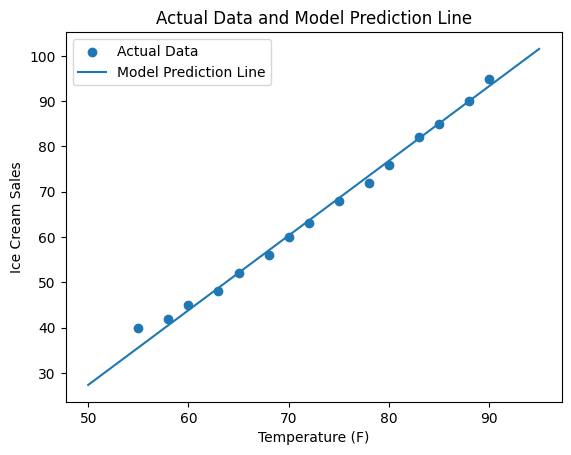

In [15]:
# Create a scatter plot of the original data.
plt.scatter(df["temperature"], df["ice_cream_sales"], label="Actual Data")

# Create many temperature values from 50°F to 95°F.
temperature_range = np.linspace(50, 95, 100)

# Convert the temperature values into a DataFrame with the correct column name.
temperature_range_df = pd.DataFrame({"temperature": temperature_range})

# Use the trained model to predict sales for all those temperatures.
sales_predictions = model.predict(temperature_range_df)

# Draw the model's prediction line.
plt.plot(temperature_range, sales_predictions, label="Model Prediction Line")

# Add labels and title.
plt.xlabel("Temperature (F)")
plt.ylabel("Ice Cream Sales")
plt.title("Actual Data and Model Prediction Line")

# Add a legend.
plt.legend()

# Show the chart.
plt.show()

# Part 7: Improve the Model

Real-world machine learning projects usually need more than one feature.

Ice cream sales may depend on:

- temperature
- whether it is a weekend
- whether it is raining
- location
- school vacation
- holiday events

Now we will add a second feature: `is_weekend`.

`is_weekend` means:

| Value | Meaning |
|---|---|
| 0 | Not weekend |
| 1 | Weekend |

## Student TODO: Create an Improved Dataset

In [16]:
# TODO: Create a dataset with two features:
# 1. temperature
# 2. is_weekend

improved_data = {
    "temperature": [55, 58, 60, 63, 65, 68, 70, 72, 75, 78, 80, 83, 85, 88, 90],
    "is_weekend":   [0,  0,  0,  0,  1,  1,  0,  0,  0,  1,  1,  0,  0,  1,  1],
    "ice_cream_sales": [40, 42, 45, 48, 58, 62, 60, 63, 68, 80, 85, 82, 85, 98, 102]
}

# Convert the dictionary into a DataFrame.
df_improved = pd.DataFrame(improved_data)

# Display the improved dataset.
df_improved

,temperature,is_weekend,ice_cream_sales
0,55,0,40
1,58,0,42
2,60,0,45
3,63,0,48
4,65,1,58
5,68,1,62
6,70,0,60
7,72,0,63
8,75,0,68
9,78,1,80


## Student TODO: Train the Improved Model

In [17]:
# TODO: Create X with two features.
X_improved = df_improved[["temperature", "is_weekend"]]

# TODO: Create y with the label.
y_improved = df_improved["ice_cream_sales"]

# TODO: Split the improved dataset.
X_train_improved, X_test_improved, y_train_improved, y_test_improved = train_test_split(
    X_improved,
    y_improved,
    test_size=0.2,
    random_state=42
)

# TODO: Create a new model.
improved_model = LinearRegression()

# TODO: Train the improved model.
improved_model.fit(X_train_improved, y_train_improved)

# TODO: Make predictions.
improved_predictions = improved_model.predict(X_test_improved)

# TODO: Calculate the error.
improved_mae = mean_absolute_error(y_test_improved, improved_predictions)

print("Improved Model MAE:", round(improved_mae, 2))

Improved Model MAE: 1.95


## Student TODO: Predict With the Improved Model

Question:

> What if the temperature is 82°F and it is a weekend?

In [18]:
# Create a new example with two features.
new_day = pd.DataFrame({
    "temperature": [82],
    "is_weekend": [1]
})

# Predict sales for the new day.
new_day_prediction = improved_model.predict(new_day)

print("Predicted ice cream sales for 82°F on a weekend:")
print(round(new_day_prediction[0], 2))

Predicted ice cream sales for 82°F on a weekend:
87.4


## Teacher Solution: Improved Model

In [19]:
# Teacher Solution

# Create improved feature table and label.
teacher_X_improved = df_improved[["temperature", "is_weekend"]]
teacher_y_improved = df_improved["ice_cream_sales"]

# Split data.
teacher_X_train_improved, teacher_X_test_improved, teacher_y_train_improved, teacher_y_test_improved = train_test_split(
    teacher_X_improved,
    teacher_y_improved,
    test_size=0.2,
    random_state=42
)

# Create and train model.
teacher_improved_model = LinearRegression()
teacher_improved_model.fit(teacher_X_train_improved, teacher_y_train_improved)

# Predict.
teacher_improved_predictions = teacher_improved_model.predict(teacher_X_test_improved)

# Calculate MAE.
teacher_improved_mae = mean_absolute_error(
    teacher_y_test_improved,
    teacher_improved_predictions
)

# Display results.
teacher_improved_results = pd.DataFrame({
    "Temperature": teacher_X_test_improved["temperature"],
    "Is Weekend": teacher_X_test_improved["is_weekend"],
    "Actual Sales": teacher_y_test_improved,
    "Predicted Sales": teacher_improved_predictions
})

display(teacher_improved_results)

print("Improved Model MAE:", round(teacher_improved_mae, 2))

# Predict new weekend day.
teacher_new_day = pd.DataFrame({
    "temperature": [82],
    "is_weekend": [1]
})

teacher_new_day_prediction = teacher_improved_model.predict(teacher_new_day)

print("Prediction for 82°F on a weekend:", round(teacher_new_day_prediction[0], 2))

,Temperature,Is Weekend,Actual Sales,Predicted Sales
9,78,1,80,80.662945
11,83,0,82,82.308154
0,55,0,40,35.120417


Improved Model MAE: 1.95
Prediction for 82°F on a weekend: 87.4


# Part 8: Reflection Questions

Answer these questions in complete sentences.

## Concept Questions

1. What is the feature in the first model?
2. What is the label in the first model?
3. What pattern did the model learn?
4. Why do we split data into training data and test data?
5. What does `model.fit()` do?
6. What does `model.predict()` do?
7. Why is this machine learning instead of traditional programming?

## Model Evaluation Questions

8. What does Mean Absolute Error mean in plain English?
9. If a model has a lower MAE, is that usually better or worse?
10. Why might the model still be wrong in the real world?

## STEM Competition Thinking

11. Why is it important to evaluate a model before using it in a science fair project?
12. What extra data could make this ice cream sales model more realistic?
13. How could this same machine learning workflow be used for an environmental, biology, health, or robotics project?

# Part 9: Challenge Task

Choose one challenge.

## Challenge Option A: Build Your Own Prediction Dataset

Create your own small dataset with at least 12 rows.

Possible project ideas:

| Project Idea | Feature | Label |
|---|---|---|
| Study prediction | Hours studied | Quiz score |
| Fitness prediction | Minutes exercised | Calories burned |
| Game analytics | Minutes played | Points scored |
| Environment | Temperature | Energy usage |
| Biology | Amount of sunlight | Plant height |

Your task:

1. Create a DataFrame.
2. Make a scatter plot.
3. Choose `X` and `y`.
4. Split the data.
5. Train a model.
6. Make one new prediction.
7. Explain whether the prediction makes sense.

## Challenge Option B: Add Another Feature

Add a third feature to the ice cream dataset.

Ideas:

- `is_raining`
- `is_holiday`
- `school_vacation`
- `near_park`

Then compare the old model and new model.

## Challenge Option C: Explain Like a Young Researcher

Write one paragraph using this structure:

> My model tries to predict ______ using ______.  
> The model learned from ______.  
> I tested the model by ______.  
> The model's average error was ______.  
> One limitation of my model is ______.  
> To improve it, I would collect ______.

## Challenge Starter Code

Use this blank template for your own dataset.

,feature_name,label_name
0,1,2
1,2,4
2,3,5
3,4,7
4,5,9
5,6,12
6,7,13
7,8,15
8,9,18
9,10,20


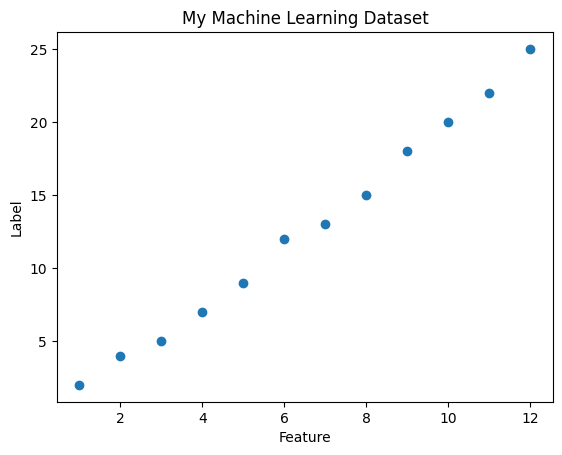

My Model MAE: 0.42
Prediction for new value: 26.4


In [20]:
# Challenge Template

# TODO: Replace the example values with your own data.
my_data = {
    "feature_name": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12],
    "label_name":   [2, 4, 5, 7, 9, 12, 13, 15, 18, 20, 22, 25]
}

# TODO: Create a DataFrame.
my_df = pd.DataFrame(my_data)

# TODO: Display your data.
display(my_df)

# TODO: Create a scatter plot.
plt.scatter(my_df["feature_name"], my_df["label_name"])
plt.xlabel("Feature")
plt.ylabel("Label")
plt.title("My Machine Learning Dataset")
plt.show()

# TODO: Prepare X and y.
my_X = my_df[["feature_name"]]
my_y = my_df["label_name"]

# TODO: Split the data.
my_X_train, my_X_test, my_y_train, my_y_test = train_test_split(
    my_X,
    my_y,
    test_size=0.2,
    random_state=42
)

# TODO: Train a model.
my_model = LinearRegression()
my_model.fit(my_X_train, my_y_train)

# TODO: Evaluate the model.
my_predictions = my_model.predict(my_X_test)
my_mae = mean_absolute_error(my_y_test, my_predictions)

print("My Model MAE:", round(my_mae, 2))

# TODO: Make a prediction for a new value.
new_value = pd.DataFrame({"feature_name": [13]})
my_new_prediction = my_model.predict(new_value)

print("Prediction for new value:", round(my_new_prediction[0], 2))

# Final Summary

In this notebook, you learned that:

1. Machine learning uses data to learn patterns.
2. A feature is the input.
3. A label is the output we want to predict.
4. Training data teaches the model.
5. Test data checks the model.
6. `model.fit()` trains the model.
7. `model.predict()` makes predictions.
8. Evaluation helps us understand whether the model is useful.
9. Adding useful features can improve a model.
10. A strong STEM competition project needs data, a model, evaluation, limitations, and improvement ideas.